# DBSCAN Clustering


We will use car data to perform DBSCAN using sklearn packages. Overview of different clustering algorithms as supported by `sklearn` can be found at: http://scikit-learn.org/stable/modules/clustering.html

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_samples, silhouette_score

import os

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")


## Preparing Data

Read data from a specified location


In [ ]:
# from google.colab import drive
# drive.mount('/content/files')

Drive already mounted at /content/files; to attempt to forcibly remount, call drive.mount("/content/files", force_remount=True).


In [ ]:
# os.getcwd()

'/content/files/My Drive/ML_using_Python/Python_Code'

In [ ]:
# path_name = "/content/files/MyDrive/ML_using_Python/Python_Code/"
# os.chdir(path_name)
# os.getcwd()

'/content/files/MyDrive/ML_using_Python/Python_Code'

In [ ]:
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

In [ ]:
raw_df = pd.read_csv( "Kmeans_Car data.csv",
                        sep = ',', na_values = ['', ' '])

raw_df.columns = raw_df.columns.str.lower().str.replace(' ', '_')
raw_df

,brand,car_models,price_(inr),mileage,seating_capacity,vehicle_type,fuel_type,transmission,parking_sensor,airbag,cruise_control,keyless_entry,alloy_wheels,abs,climate_control,rear_ac_vent,power_steering
0,Tata,Tata Nano Std BSIII,141898,25.40,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No
1,Tata,Tata Nano Std,145000,25.40,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No
2,Tata,Tata Nano 2013 STD,150000,25.40,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No
3,Tata,Tata Nano Cx BSIII,171489,25.40,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No
4,Tata,Tata Nano Cx,191125,25.40,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,Rolls Royce,Rolls Royce Wraith Coupe,46000000,12.24,4,Coupe,Petrol,Automatic,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes
1004,Maybach,Maybach 57 S,48500000,8.47,4,Luxury,Petrol,Automatic,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
1005,Conquest,Conquest Evade SUV,85000000,5.00,6,SUV,Diesel,Automatic,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes
1006,Bugatti,Bugatti Veyron 16.4 Grand Sport,120000000,5.20,2,Convertible,Petrol,Automatic,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes


In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             1008 non-null   object 
 1   car_models        1008 non-null   object 
 2   price_(inr)       1008 non-null   int64  
 3   mileage           1008 non-null   float64
 4   seating_capacity  1008 non-null   int64  
 5   vehicle_type      1008 non-null   object 
 6   fuel_type         1008 non-null   object 
 7   transmission      1008 non-null   object 
 8   parking_sensor    1008 non-null   object 
 9   airbag            1008 non-null   object 
 10  cruise_control    1008 non-null   object 
 11  keyless_entry     1008 non-null   object 
 12  alloy_wheels      1008 non-null   object 
 13  abs               1008 non-null   object 
 14  climate_control   1008 non-null   object 
 15  rear_ac_vent      1008 non-null   object 
 16  power_steering    1008 non-null   object 


In [ ]:
raw_df.describe()

,price_(inr),mileage,seating_capacity
count,1.008000e+03,1008.000000,1008.000000
mean,3.767875e+06,16.181885,5.358135
std,8.799889e+06,6.085492,1.407073
min,1.418980e+05,4.000000,2.000000
25%,6.044420e+05,12.800000,5.000000
50%,8.877020e+05,15.640000,5.000000
75%,2.658200e+06,19.490000,5.000000
max,1.250000e+08,100.000000,10.000000



## 2. Extract Features and Standardize

Two ways to extract the features:

> * use `pd.filter` and pass the list of features to extract for scaling
* Use `pd.drop` and pass the list of features which need not be extracted

The feature can also be extracted by using `dataframeName[[<name of features>]]`


In [ ]:
#feature_df = raw_df[['price_(inr)','mileage', 'seating_capacity']]

feature_df = raw_df.filter({'price_(inr)','mileage', 'seating_capacity'}, axis =1)
col_names = feature_df.columns

row_index = raw_df.iloc[:,2]
#row_index

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(feature_df))

scaled_data.columns = col_names
#scaled_data.index = row_index

scaled_data.head()

,seating_capacity,price_(inr),mileage
0,-0.965699,-0.412253,1.515521
1,-0.965699,-0.411900,1.515521
2,-0.965699,-0.411331,1.515521
3,-0.965699,-0.408888,1.515521
4,-0.965699,-0.406656,1.515521


In [ ]:
#sns.pairplot(scaled_data, height=5);

## Choosing eps based on KNN

We will use nearest neighbour to find the optimal eps. If the eps value is chosen too small then large part of the data will be considered as outliers. If it is chosen very large then the clusters will merge and majority of the data points will be in the same clusters.

In [ ]:
nn = NearestNeighbors(n_neighbors=20).fit(scaled_data)
distances, indices = nn.kneighbors(scaled_data)

plot the distances of each point in ascending order of the distance, elbow point will give us the samller range for optimal eps value.

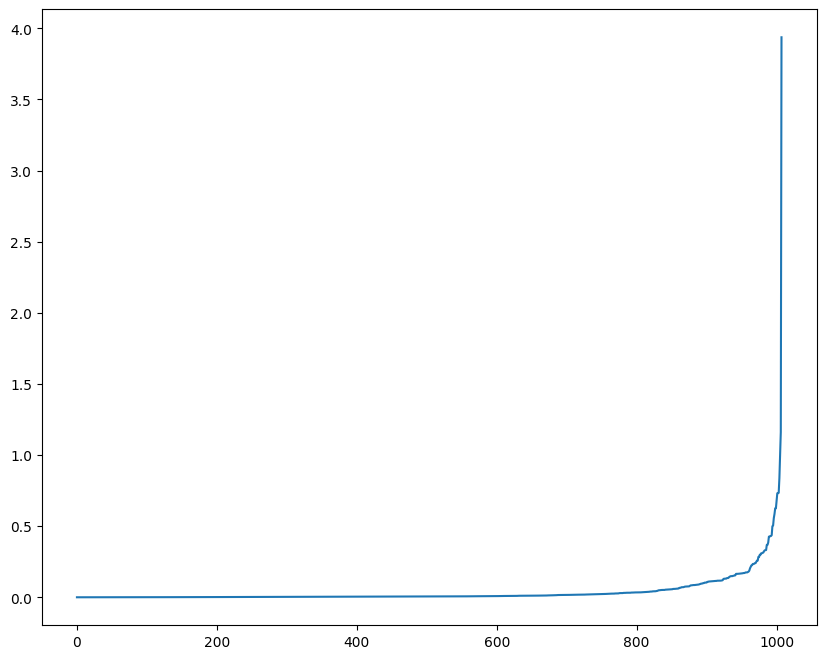

In [ ]:
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(10,8))
plt.plot(distances)

Lets consider eps range 0.05 to 0.013 and _min_sample_ range 6 to 30 and iterate over these combinations and get the best silhouette score. This is like a grid search which we perform using model_selection module of sklearn, generally.

In [ ]:
min_samples = range(6,20)
eps = np.arange(0.02,0.3, 0.01)

In [ ]:
output = []

for ms in min_samples:
    for ep in eps:
        labels = DBSCAN(min_samples=ms, eps = ep).fit(scaled_data).labels_
        score = silhouette_score(scaled_data, labels)
        output.append((ms, ep, score))

Get the parameters for best silhouette score

In [ ]:
min_samples, eps, score = sorted(output, key=lambda x:x[-1])[-1]
print(f"Best silhouette_score: {score}")
print(f"min_samples: {min_samples}")
print(f"eps: {eps}")

Best silhouette_score: 0.428790298412004
min_samples: 12
eps: 0.24999999999999994


Get the number of clusters and outliers for DBSCAN with best parameters

In [ ]:
db_model = DBSCAN(min_samples=min_samples, eps = 0.25).fit(scaled_data)
label=db_model.labels_
clusters = len(set(labels))

print(f"Silhouette_score: {silhouette_score(scaled_data, labels)}")
n_clusters=len(set(label))- (1 if -1 in label else 0)
print('No of clusters:',n_clusters)


Silhouette_score: 0.37529734040915724
No of clusters: 5


In [ ]:
#scaled_data['clusters'] = db_model.fit_predict(scaled_data)
scaled_data['clusters'] = label
print("Frequency of DBScan Output Cluster v1")
print(scaled_data.clusters.value_counts())

Frequency of DBScan Output Cluster v1
 0    617
-1    194
 2    120
 1     48
 4     17
 3     12
Name: clusters, dtype: int64


In [ ]:
scaled_data['clusters'] = db_model.fit_predict(scaled_data)

print("Frequency of DBScan Output Cluster v1")
print(scaled_data.clusters.value_counts())

Frequency of DBScan Output Cluster v1
 0    617
-1    194
 2    120
 1     48
 4     17
 3     12
Name: clusters, dtype: int64


In [ ]:
raw_df['cluster'] = label

raw_df.head()

,brand,car_models,price_(inr),mileage,seating_capacity,vehicle_type,fuel_type,transmission,parking_sensor,airbag,cruise_control,keyless_entry,alloy_wheels,abs,climate_control,rear_ac_vent,power_steering,cluster
0,Tata,Tata Nano Std BSIII,141898,25.4,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No,-1
1,Tata,Tata Nano Std,145000,25.4,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No,-1
2,Tata,Tata Nano 2013 STD,150000,25.4,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No,-1
3,Tata,Tata Nano Cx BSIII,171489,25.4,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No,-1
4,Tata,Tata Nano Cx,191125,25.4,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No,-1


In [ ]:
unclustered_df = raw_df[raw_df['cluster'] == -1]


In [ ]:
unclustered_df.car_models.unique()

array(['Tata Nano Std BSIII', 'Tata Nano Std', 'Tata Nano 2013 STD',
       'Tata Nano Cx BSIII', 'Tata Nano Cx', 'Tata Nano 2013 CX',
       'Tata Nano Lx BSIII', 'Tata Nano Lx', 'Tata Nano 2013 LX',
       'Tata Nano Twist XT', 'Tata Nano CNG CX', 'Tata Nano CNG LX',
       'Maruti 800 Std BSIII', 'Maruti 800 AC BSIII',
       'Maruti Alto 800 CNG Base', 'Maruti Alto 800 CNG LX',
       'Maruti Alto 800 CNG LXI', 'Chevrolet Enjoy TCDi LS 8 Seater',
       'San Motors Storm 1.2', 'Maruti Ertiga LXI CNG',
       'Maruti Ertiga VXI CNG', 'Force Gurkha Soft Top BS3 2WD',
       'Force Gurkha Soft Top BS3 4WD', 'Mahindra e2o T0',
       'Mahindra e2o T2', 'Mahindra Xylo D2 Maxx',
       'Mahindra Xylo D2 Maxx BSIV', 'Ashok Leyland Stile LE',
       'Ashok Leyland Stile LS 8 Seater',
       'Ashok Leyland Stile LX 8 Seater', 'Force One SX 6 Seating',
       'Force One SX ABS 6 Seating', 'Volkswagen Beetle 2.0',
       'DC Avanti 2.0 L', 'Mini Cooper S',
       'Mercedes Benz C Class C 63 A

From DBSCAN we got to know the number of clusters present, which are 5, with silhouette score of 0.42. Lets try KMeans with K ranging from (4,15)

In [ ]:
from sklearn.cluster import KMeans
output = []
k_values = range(4,15)
for k in k_values:
    labels = KMeans(n_clusters=k).fit(scaled_data).labels_
    score = silhouette_score(scaled_data, labels)
    output.append((k, score))

In [ ]:
k, score = sorted(output, key=lambda x:x[-1])[-1]
print(f"Best silhouette_score: {score}")
print(f"k: {k}")

Best silhouette_score: 0.6121826275849711
k: 5


### HDBSCAN

In [ ]:
# pip install hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.3 MB/s eta 0:00:00a 0:00:010m
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import hdbscan
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

In [ ]:
# Extract features for clustering
features = raw_df.filter(['price_(inr)', 'mileage', 'seating_capacity'], axis=1).values

# Parameter ranges to test
min_samples_range = range(6,20)
min_cluster_sizes = [5, 10, 20, 30, 50]

# To store results
results = []

In [ ]:
# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
# Iterate through combinations of min_samples and min_cluster_size
for min_samples in min_samples_range:
    for min_cluster_size in min_cluster_sizes:
        # Build HDBSCAN model
        clusterer = hdbscan.HDBSCAN(min_samples=min_samples, min_cluster_size=min_cluster_size).fit(scaled_features)

        # Exclude noise (-1) labels for silhouette score
        labels = clusterer.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Exclude noise

        if n_clusters > 1:  # Silhouette score is undefined for 1 cluster
            silhouette = silhouette_score(scaled_features, labels)
        else:
            silhouette = -1  # Invalid silhouette score

        # Store the results
        results.append({
            "min_samples": min_samples,
            "min_cluster_size": min_cluster_size,
            "num_clusters": n_clusters,
            "silhouette_score": silhouette
        })

# Convert results to a DataFrame for analysis
results_df = pd.DataFrame(results)

# Display the top results based on silhouette score
print("Top configurations based on silhouette score:")
print(results_df.sort_values(by='silhouette_score', ascending=False).head())

Top configurations based on silhouette score:
    min_samples  min_cluster_size  num_clusters  silhouette_score
13            8                30             5          0.427523
18            9                30             5          0.427504
28           11                30             5          0.427102
23           10                30             5          0.425807
52           16                20             5          0.424943


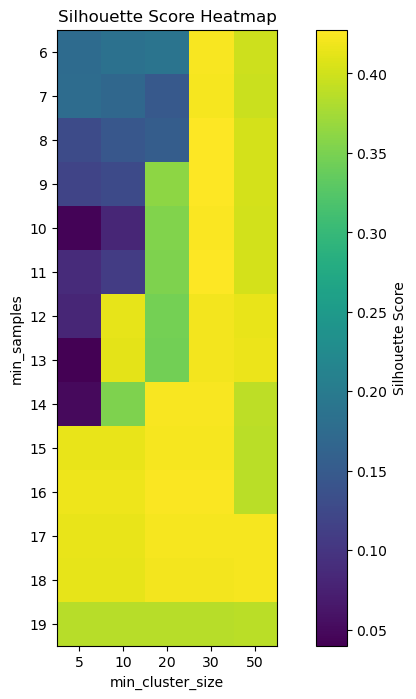

In [ ]:
# Plot results to visualize the impact of parameters
pivot = results_df.pivot_table(
    values="silhouette_score",
    index="min_samples",
    columns="min_cluster_size",
    aggfunc="mean"
)

plt.figure(figsize=(10, 8))
plt.title("Silhouette Score Heatmap")
plt.xlabel("min_cluster_size")
plt.ylabel("min_samples")
plt.imshow(pivot, cmap="viridis", interpolation="nearest")
plt.colorbar(label="Silhouette Score")
plt.xticks(range(len(min_cluster_sizes)), min_cluster_sizes)
plt.yticks(range(len(min_samples_range)), min_samples_range)
plt.show()

In [ ]:
# Select the best parameters
best_params = results_df.sort_values(by="silhouette_score", ascending=False).iloc[0]
# best_min_samples = 7
best_min_samples = int(best_params["min_samples"])
best_min_cluster_size = int(best_params["min_cluster_size"])

print(f"Best Parameters: min_samples={best_min_samples}, min_cluster_size={best_min_cluster_size}")

Best Parameters: min_samples=8, min_cluster_size=30


In [ ]:
# Re-run HDBSCAN with the best parameters
final_clusterer = hdbscan.HDBSCAN(min_samples=best_min_samples, min_cluster_size=best_min_cluster_size).fit(scaled_features)

# Add cluster labels to the original dataset
raw_df["Cluster"] = final_clusterer.labels_

In [ ]:
# Print cluster summary
n_clusters = len(set(final_clusterer.labels_)) - (1 if -1 in final_clusterer.labels_ else 0)

print(f"Silhouette_score: {silhouette_score(scaled_features, labels)}")
print(f"Number of clusters: {n_clusters}")
print("Cluster labels distribution:")
print(raw_df["Cluster"].value_counts())

Silhouette_score: 0.3879971018753465
Number of clusters: 5
Cluster labels distribution:
Cluster
 2    660
 3    137
 4     68
 1     53
-1     52
 0     38
Name: count, dtype: int64


## Exercise:

Use dbscan from sklearn.cluster to build Kmeans Clustering using the beer data. What challenges do you encounter?